In [1]:
import sys
import os

from bertopic import BERTopic
from bertopic.vectorizers import ClassTfidfTransformer
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import classification_report
from transformers import pipeline, AutoModelForSequenceClassification, AutoTokenizer

sys.path.insert(0, os.path.dirname(os.getcwd()))

from src.models.preprocessing_utils import Preprocess

/opt/homebrew/Caskroom/miniforge/base/envs/voc_env/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
pd.set_option('display.max_columns', None)
data = pd.read_table("../data/raw/Restaurant_Reviews.tsv")

In [3]:
print(data.isna().any())

docs = list(data["Review"])
label = list(data["Liked"])

Review    False
Liked     False
dtype: bool


## Sentiment Analysis using Huggingface Transformers (DistilBERT)

In [4]:
sentiment_pipeline = pipeline("sentiment-analysis", "distilbert-base-uncased-finetuned-sst-2-english")
pred_dict = sentiment_pipeline(docs)
pred_dict

[{'label': 'POSITIVE', 'score': 0.9998804330825806},
 {'label': 'NEGATIVE', 'score': 0.9997690320014954},
 {'label': 'NEGATIVE', 'score': 0.9996275901794434},
 {'label': 'POSITIVE', 'score': 0.9995303153991699},
 {'label': 'POSITIVE', 'score': 0.9996086955070496},
 {'label': 'NEGATIVE', 'score': 0.992295503616333},
 {'label': 'NEGATIVE', 'score': 0.9909782409667969},
 {'label': 'NEGATIVE', 'score': 0.9024146199226379},
 {'label': 'POSITIVE', 'score': 0.9997226595878601},
 {'label': 'POSITIVE', 'score': 0.9998835325241089},
 {'label': 'POSITIVE', 'score': 0.9962829947471619},
 {'label': 'NEGATIVE', 'score': 0.9978346228599548},
 {'label': 'NEGATIVE', 'score': 0.9997603297233582},
 {'label': 'NEGATIVE', 'score': 0.9762391448020935},
 {'label': 'NEGATIVE', 'score': 0.9994242191314697},
 {'label': 'NEGATIVE', 'score': 0.997475802898407},
 {'label': 'POSITIVE', 'score': 0.9998443126678467},
 {'label': 'NEGATIVE', 'score': 0.9995195865631104},
 {'label': 'NEGATIVE', 'score': 0.99980813264846

In [5]:
pred_labels = [1 if elem_dict["label"] == 'POSITIVE' else 0 for elem_dict in pred_dict]
labelled_data = pd.DataFrame({"reviews": docs, "true_label": label, "pred_label": pred_labels})

In [6]:
print(classification_report(label, pred_labels))

              precision    recall  f1-score   support

           0       0.93      0.92      0.92       500
           1       0.92      0.93      0.92       500

    accuracy                           0.92      1000
   macro avg       0.92      0.92      0.92      1000
weighted avg       0.92      0.92      0.92      1000



## Sentiment Analysis using Huggingface Transformers (DistilBERT) - Manual Implementation

Don't run, still in progress

In [45]:
model = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased-finetuned-sst-2-english")
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased-finetuned-sst-2-english")

In [48]:
tokens = tokenizer.tokenize("I am so happy today.")
token_ids = tokenizer.convert_tokens_to_ids(tokens)
input_ids = tokenizer("I am so happy today.")

print(f' Tokens:{tokens}')
print(f'Token IDs: {token_ids}')
print(f'Input IDs: {input_ids}')


 Tokens:['i', 'am', 'so', 'happy', 'today', '.']
Token IDs: [1045, 2572, 2061, 3407, 2651, 1012]
Input IDs: {'input_ids': [101, 1045, 2572, 2061, 3407, 2651, 1012, 102], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1]}


In [50]:
# Store length of each review 
token_lens = []

# Iterate through the content slide
for txt in docs:
    tokens = tokenizer.encode(txt, max_length=512)
    token_lens.append(len(tokens))

Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.


NameError: name 'plt' is not defined

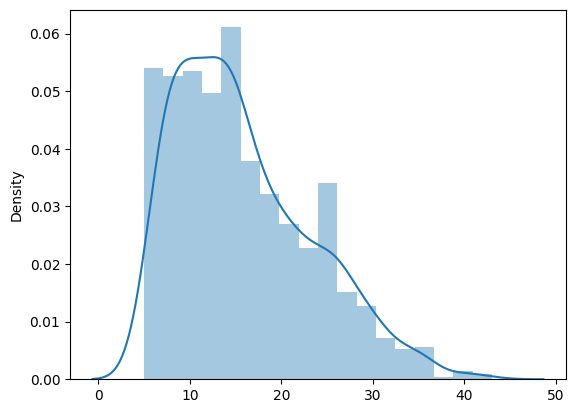

In [51]:
sns.distplot(token_lens)
plt.xlim([0, 256]);
plt.xlabel('Token count')

# Topic Modelling: BERTopic

In [7]:
pos_docs = list(labelled_data.query("pred_label == 1")["reviews"])

In [9]:
vectorizer_model = CountVectorizer(stop_words="english")
ctfidf_model = ClassTfidfTransformer(reduce_frequent_words=True)
model_bert = BERTopic(vectorizer_model=vectorizer_model, ctfidf_model=ctfidf_model)
topics, probs = model_bert.fit_transform(pos_docs)

In [10]:
model_bert.get_representative_docs()

{0: ['Pretty awesome place.',
  'I love this place.',
  "It's a great place and I highly recommend it."],
 2: ['They were golden-crispy and delicious.',
  'The pancake was also really good and pretty large at that.',
  'I can say that the desserts were yummy.'],
 8: ['Both great!', 'Overall, a great experience.', 'A good time!'],
 1: ['Great food and great service in a clean and friendly setting.',
  'Service was very prompt.',
  'Fantastic service here.'],
 5: ['definitely will come back here again.',
  "I'd love to go back.",
  'Def coming back to bowl next time'],
 4: ['The owners are super friendly and the staff is courteous.',
  'The waitresses are very friendly.',
  'Our waiter was very attentive, friendly, and informative.'],
 3: ['Never been to Hard Rock Casino before, WILL NEVER EVER STEP FORWARD IN IT AGAIN!',
  'My boyfriend and I came here for the first time on a recent trip to Vegas and could not have been more pleased with the quality of food and service.',
  "The chains,

In [11]:
model_bert.visualize_barchart()
#fig.write_html("path/to/file.html")